# Social Discounting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import truncnorm, beta as beta_dist
from pyem import EMModel
from pyem.utils.math import norm2beta, norm2alpha
from pyem.utils import plotting

from pyem.models.social_discounting import (
    TASK1_PAYOUTS,
    TASK2_PAYOUTS,
    DEFAULT_SOCIAL_DISTS,
    hsd_sim, hsd_fit,
    esd_sim, esd_fit
)

rng = np.random.default_rng(2026)

# choose task
payouts = TASK1_PAYOUTS.copy()
# payouts = TASK2_PAYOUTS.copy()

social_dists = DEFAULT_SOCIAL_DISTS.copy()
nsubjects = 100

# parameter ranges
betamin, betamax = 1, 4.25
wmin, wmax = 0.05, 0.95
kmin, kmax = 0.001, 0.25

def draw_positive(n, lo, hi, loc=0.0, scale=2.0):
    a = (lo - loc) / scale
    b = (hi - loc) / scale
    return truncnorm(a, b, loc=loc, scale=scale).rvs(n, random_state=rng)

def draw_unit_interval(n, lo=0.05, hi=0.95, a=1.1, b=1.1):
    lo_cdf, hi_cdf = beta_dist.cdf([lo, hi], a, b)
    u = lo_cdf + rng.random(n) * (hi_cdf - lo_cdf)
    return beta_dist.ppf(u, a, b)

def draw_beta_vals(n):
    return draw_positive(n, betamin, betamax, loc=0.0, scale=2.0)

def draw_k_vals(n):
    return draw_positive(n, kmin, kmax, loc=0.0, scale=0.08)

536.0481 (000), 378.3950 (001), 329.3380 (002), 328.4957 (003), 328.4857 (004), 328.4852 (005), 

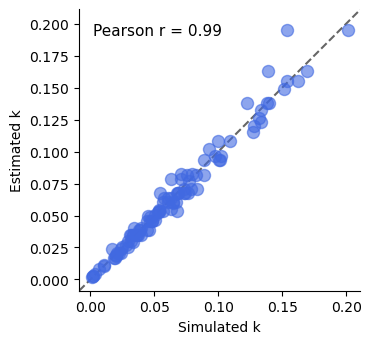

In [2]:
true_params = draw_k_vals(nsubjects).reshape(-1, 1)

sim = hsd_sim(true_params, payouts=payouts, social_dists=social_dists,)
all_data = [[c, p, d] for c, p, d in zip(sim["choices"], sim["payouts"], sim["social_dists"])]

# Create and fit model
model = EMModel(
    all_data=all_data,
    fit_func=hsd_fit,
    param_names=["k"],
    param_xform=[norm2beta], # Parameter transformation functions
)

# Fit the model
result = model.fit(verbose=1)

# Plot recovery
for param_idx, param_label in enumerate(['k']):
    simulated_param = sim['params'][:,param_idx]
    estimated_param = model.outfit['params'][:,param_idx]
    ax = plotting.plot_scatter(simulated_param, f'Simulated {param_label}', 
                 estimated_param, f'Estimated {param_label}')

In [3]:
import pandas as pd

_, nblocks, ntrials = model.outfit['delta_V'].shape
df = pd.DataFrame({
    "subj_idx": np.repeat(np.arange(nsubjects), nblocks * ntrials),
    "social distance (N)": np.repeat(model.outfit['social_dists'].reshape(-1), ntrials),
    "trial_idx": np.tile(np.arange(ntrials), nsubjects * nblocks),
    "value (geneous - selfish)": model.outfit['delta_V'].reshape(-1),
    "prosocial choice": model.outfit['choices_prosocial'].reshape(-1),
    "utility (other)": model.outfit['U_other'].reshape(-1),
    "self payout": np.tile(TASK1_PAYOUTS[:, 0, 0, ...], nsubjects * nblocks),
})

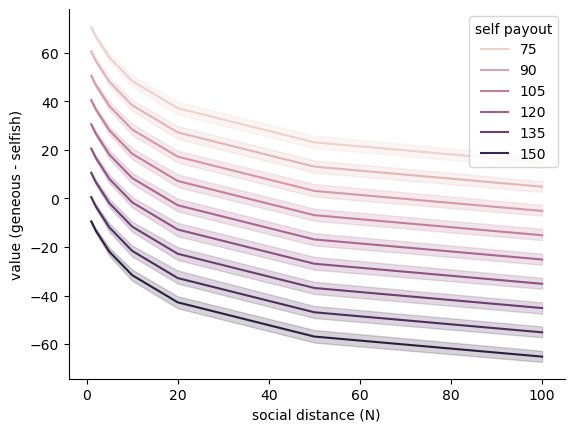

In [4]:
sns.lineplot(data=df, x='social distance (N)', y='value (geneous - selfish)', hue='self payout')
sns.despine()

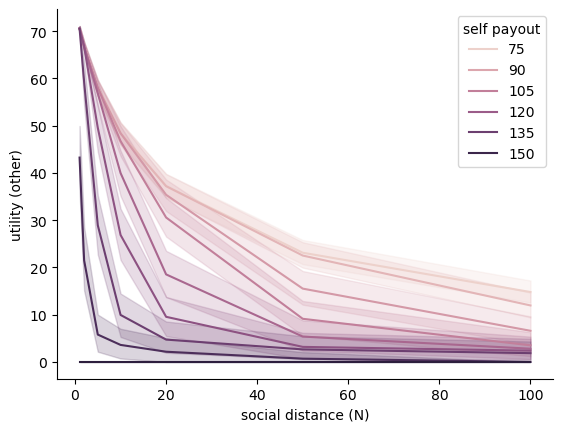

In [5]:
sns.lineplot(data=df, y='utility (other)', x='social distance (N)', hue='self payout')
sns.despine()

**References**

Rhoads, S. A., Vekaria, K. M., O’Connell, K., Elizabeth, H. S., Rand, D. G., Kozak Williams, M. N., & Marsh, A. A. (2023). Unselfish traits and social decision-making patterns characterize six populations of real-world extraordinary altruists. Nature Communications, 14(1), 1807.

Rhoads, S. A., O'Connell, K., Berluti, K., Ploe, M. L., Elizabeth, H. S., Amormino, P., ... & Marsh, A. A. (2023). Neural responses underlying extraordinary altruists’ generosity for socially distant others. PNAS nexus, 2(7), pgad199.